# ElSherief Formatting Notebook

This notebook formats the **ElSherief implicit hate corpus** into the shared post-level schema used by downstream union/dedup steps.

## What this notebook does
1. Loads the ElSherief TSV file from local disk.
2. Maps raw columns to standardized columns.
3. Normalizes targets and text-dedup keys.
4. Saves output to `outputs/preprocessing/elsherief_standardized.tsv`.

## Output schema
- `post_id`
- `text`
- `raw_label`
- `binary_hate`
- `targets`
- `dataset`
- `text_dedup_key`

In [5]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional
import json
import re

import pandas as pd

# Resolve workspace root robustly for both editor and command-line execution.
WORKDIR = Path.cwd()
if not (WORKDIR / 'data').exists():
    WORKDIR = Path('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles')

@dataclass
class ElSheriefConfig:
    # Local source file location.
    source_path: Path = WORKDIR / 'data' / 'implicit-hate-corpus' / 'implicit_hate_v1_stg3_posts.tsv'

    # Shared-schema output location.
    output_path: Path = WORKDIR / 'outputs' / 'preprocessing' / 'elsherief_standardized.tsv'

cfg = ElSheriefConfig()
cfg.output_path.parent.mkdir(parents=True, exist_ok=True)
cfg

ElSheriefConfig(source_path=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/data/implicit-hate-corpus/implicit_hate_v1_stg3_posts.tsv'), output_path=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/elsherief_standardized.tsv'))

In [6]:
def normalize_text_for_dedup(text: str) -> str:
    """Create a lowercase, whitespace-normalized text key for dedup fallback."""
    if not isinstance(text, str):
        return ''
    return re.sub(r'\s+', ' ', text.strip().lower())


def normalize_target_token(token: str) -> Optional[str]:
    """Normalize one target token to a stable lowercase form."""
    if token is None:
        return None
    value = str(token).strip().lower().replace('_', ' ')
    if not value or value in {'none', 'null', 'nan'}:
        return None
    return value


def parse_targets_generic(value) -> List[str]:
    """Normalize mixed target payloads into a clean list[str]."""
    if value is None:
        return []

    if isinstance(value, (list, tuple, set)):
        candidates = list(value)
    elif isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = json.loads(s.replace("'", '"'))
                candidates = parsed if isinstance(parsed, list) else [parsed]
            except Exception:
                candidates = [s]
        elif '|' in s:
            candidates = [x.strip() for x in s.split('|')]
        elif ',' in s:
            candidates = [x.strip() for x in s.split(',')]
        else:
            candidates = [s]
    else:
        try:
            if pd.isna(value):
                return []
        except Exception:
            pass
        candidates = [value]

    normalized = []
    for candidate in candidates:
        token = normalize_target_token(candidate)
        if token:
            normalized.append(token)
    return sorted(set(normalized))


def label_to_binary(label_value) -> Optional[int]:
    """Map heterogeneous label strings to binary hate values where possible."""
    if label_value is None:
        return None

    try:
        if pd.isna(label_value):
            return None
    except Exception:
        pass

    s = str(label_value).strip().lower()

    if s in {'hate', 'hateful', 'hatespeech', 'implicit_hate', 'explicit_hate', '1', 'true', 'yes'}:
        return 1
    if s in {'normal', 'non-hate', 'non_hate', 'offensive', 'not_hate', '0', 'false', 'no'}:
        return 0
    return None


def serialize_targets_for_tsv(value) -> str:
    """Serialize list-like targets as pipe-delimited strings for TSV output."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ''
    if isinstance(value, list):
        return '|'.join(str(x) for x in value)
    return str(value)

In [7]:
def harmonize_elsherief(df: pd.DataFrame) -> pd.DataFrame:
    """Map ElSherief fields into the common standardized schema."""
    required = ['post']
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f'ElSherief columns missing: {missing}')

    out = pd.DataFrame()

    # Preserve original IDs when available.
    out['post_id'] = df['ID'].astype(str) if 'ID' in df.columns else pd.Series(df.index).astype(str)

    # Keep original post text but coerce to string for schema consistency.
    out['text'] = df['post'].astype(str)

    # Preserve raw label payload when present and map to binary if label vocabulary is recognizable.
    if 'class' in df.columns:
        out['raw_label'] = df['class']
        out['binary_hate'] = df['class'].apply(label_to_binary).astype('Int64')
    else:
        # Fallback assumption from original pipeline: corpus rows are hateful when no explicit class is provided.
        out['raw_label'] = None
        out['binary_hate'] = pd.Series([1] * len(df), dtype='Int64')

    if 'target' in df.columns:
        out['targets'] = df['target'].apply(parse_targets_generic)
    else:
        out['targets'] = [[] for _ in range(len(df))]

    out['dataset'] = 'elsherief'
    out['text_dedup_key'] = out['text'].apply(normalize_text_for_dedup)

    # Keep one row per post ID in final standardized export.
    out = out.drop_duplicates(subset=['post_id'], keep='first').copy()
    return out


def dataframe_for_tsv(df: pd.DataFrame) -> pd.DataFrame:
    """Convert list columns into stable string-safe TSV representations."""
    export_df = df.copy()
    export_df['targets'] = export_df['targets'].apply(serialize_targets_for_tsv)
    return export_df

In [8]:
if not cfg.source_path.exists():
    raise FileNotFoundError(f'Missing ElSherief file: {cfg.source_path}')

els_raw = pd.read_csv(cfg.source_path, sep='\t')
els_std = harmonize_elsherief(els_raw)
els_std_tsv = dataframe_for_tsv(els_std)

els_std_tsv.to_csv(cfg.output_path, sep='\t', index=False)

print('Saved ElSherief standardized output to:', cfg.output_path)
print('Rows written:', len(els_std_tsv))
display(els_std.head(3))

Saved ElSherief standardized output to: /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/elsherief_standardized.tsv
Rows written: 6359


,post_id,text,raw_label,binary_hate,targets,dataset,text_dedup_key
0,0,"rt "" white privilege "" "" is when the gun jam...",None,1,[minority groups],elsherief,"rt "" white privilege "" "" is when the gun jams ..."
1,1,if you are white in that state watch yourself !,None,1,[non-white people],elsherief,if you are white in that state watch yourself !
2,2,so the 500 % increase in h1b visas ? yeah i'm ...,None,1,[immigrants],elsherief,so the 500 % increase in h1b visas ? yeah i'm ...


Side-by-side target label comparison table:


,target_label,count_all,percentage_all,count_filtered,percentage_filtered
0,immigrants,823,12.89,823,12.89
1,white people,761,11.92,761,11.92
2,minorities,744,11.65,744,11.65
3,muslims,604,9.46,604,9.46
4,jews,446,6.99,446,6.99
...,...,...,...,...,...
560,young atheists,1,0.02,1,0.02
561,young black men,1,0.02,1,0.02
562,young white men,1,0.02,1,0.02
563,zionist,1,0.02,1,0.02


target_label,count,percentage
immigrants,823,12.89
white people,761,11.92
minorities,744,11.65
muslims,604,9.46
jews,446,6.99
blacks,270,4.23
black people,270,4.23
non-white people,256,4.01
whites,238,3.73
liberals,120,1.88


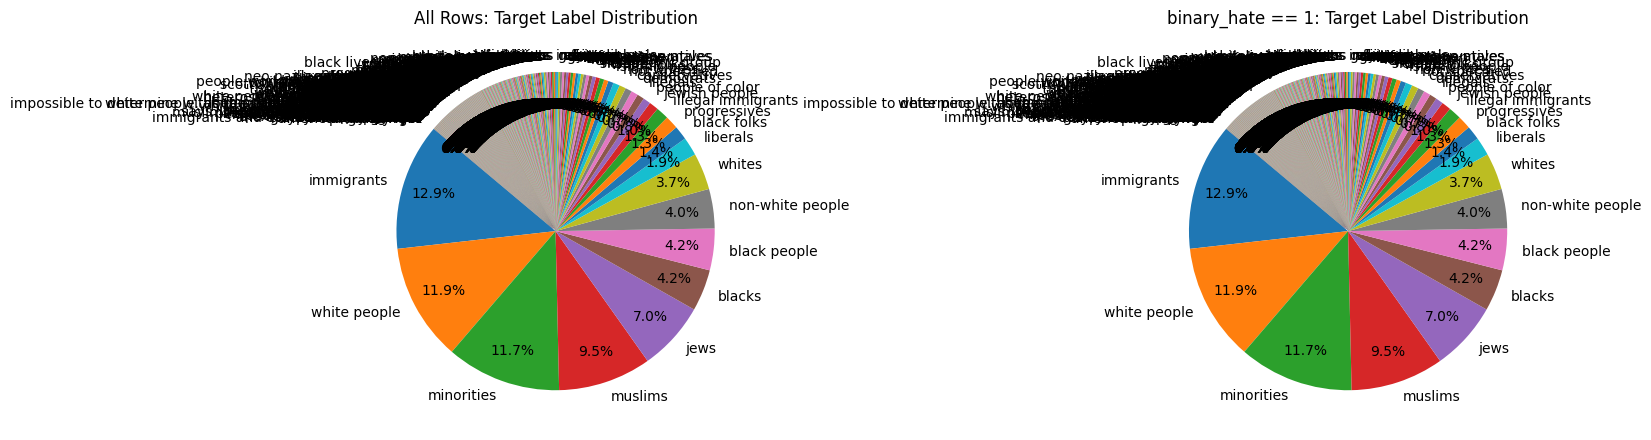

In [ ]:
# Groupwise target-label summary for ElSherief.
# Note: in this dataset, rows are effectively binary_hate == 1, so a single table/plot is sufficient.

import matplotlib.pyplot as plt
from IPython.display import display


def build_target_distribution(df: pd.DataFrame, targets_col: str = 'targets') -> pd.DataFrame:
    """Return count/percentage distribution from mixed target representations."""
    flat_labels = []

    for value in df[targets_col]:
        # parse_targets_generic handles list, tuple, set, plain strings, and list-like strings.
        labels = parse_targets_generic(value)
        if labels:
            flat_labels.extend(labels)

    if not flat_labels:
        return pd.DataFrame(columns=['target_label', 'count', 'percentage'])

    dist = pd.Series(flat_labels).value_counts().rename_axis('target_label').reset_index(name='count')
    dist['percentage'] = (dist['count'] / dist['count'].sum() * 100).round(2)
    return dist


# Build one distribution from the full standardized dataframe.
work_df = els_std.copy()
work_df['binary_hate'] = pd.to_numeric(work_df['binary_hate'], errors='coerce').astype('Int64')

target_dist = build_target_distribution(work_df)

print('Target label distribution (count and percentage):')
display(target_dist)

# Single pie chart for overall target composition.
plt.figure(figsize=(8, 8))
if not target_dist.empty:
    plt.pie(
        target_dist['count'],
        labels=target_dist['target_label'],
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.8,
    )
    plt.title('ElSherief Target Label Distribution')
else:
    plt.text(0.5, 0.5, 'No target labels', ha='center', va='center')
    plt.title('ElSherief Target Label Distribution')

plt.tight_layout()
plt.show()